#  AI-Driven Screening for Carbon Capture Materials
### Predicting CO₂ Uptake in Metal-Organic Frameworks (MOFs)

**Goal:** Build a machine learning model that predicts CO₂ uptake capacity  
of a MOF purely from its geometric structure — enabling rapid screening  
of 90,000+ candidates without expensive lab experiments.

---

##  Step 1 — Import libraries for EDA

In [304]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

##  Step 2 — Load Data

In [305]:
df = pd.read_csv("C://Users//HP//OneDrive//Documents//carbon_capture//data.csv")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (324426, 42)
Columns: ['MOFname', 'CO2_uptake_P0.15bar_T298K [mmol/g]', 'CO2_uptake_error_P0.15bar_T298K [mmol/g]', 'heat_adsorption_CO2_P0.15bar_T298K [kcal/mol]', 'heat_adsorption_error_CO2_P0.15bar_T298K [kcal/mol]', 'excess_CO2_uptake_P0.15bar_T298K [mmol/g]', 'CO2_uptake_P0.10bar_T363K [mmol/g]', 'CO2_uptake_error_P0.10bar_T363K [mmol/g]', 'heat_adsorption_CO2_P0.10bar_T363K [kcal/mol]', 'heat_adsorption_error_CO2_P0.10bar_T363K [kcal/mol]', 'excess_CO2_uptake_P0.10bar_T363K [mmol/g]', 'CO2_uptake_P0.70bar_T413K [mmol/g]', 'CO2_uptake_error_P0.70bar_T413K [mmol/g]', 'heat_adsorption_CO2_P0.70bar_T413K [kcal/mol]', 'heat_adsorption_error_CO2_P0.70bar_T413K [kcal/mol]', 'excess_CO2_uptake_P0.70bar_T413K [mmol/g]', 'working_capacity_vacuum_swing [mmol/g]', 'working_capacity_temperature_swing [mmol/g]', 'CO2_binary_uptake_P0.15bar_T298K [mmol/g]', 'CO2_binary_uptake_error_P0.15bar_T298K [mmol/g]', 'heat_adsorption_CO2_binary_P0.15bar_T298K [kcal/mol]', 'heat_adsorption_error_CO

##  Step 3 — Basic Inspection
Check data types and first few rows to understand what each column represents.

In [306]:
df.head()

,MOFname,CO2_uptake_P0.15bar_T298K [mmol/g],CO2_uptake_error_P0.15bar_T298K [mmol/g],heat_adsorption_CO2_P0.15bar_T298K [kcal/mol],heat_adsorption_error_CO2_P0.15bar_T298K [kcal/mol],excess_CO2_uptake_P0.15bar_T298K [mmol/g],CO2_uptake_P0.10bar_T363K [mmol/g],CO2_uptake_error_P0.10bar_T363K [mmol/g],heat_adsorption_CO2_P0.10bar_T363K [kcal/mol],heat_adsorption_error_CO2_P0.10bar_T363K [kcal/mol],...,void_fraction,void_volume [cm^3/g],largest_free_sphere_diameter [A],largest_included_sphere_along_free_sphere_path_diameter [A],largest_included_sphere_diameter [A],functional_groups,metal_linker,organic_linker1,organic_linker2,topology
0,str_m5_o16_o16_sra_sym.77,5.955197,0.117622,9.223227,0.546586,5.955127,0.840043,0.295803,7.972884,5.106942,...,0.14835,0.1480,4.61370,3.78047,4.61370,Pr,9,16,16,sra
1,str_m5_o16_o16_sra_sym.37,5.715251,0.034598,8.391884,0.149962,5.715251,0.901656,0.283054,8.343676,4.785696,...,0.16099,0.1624,4.10210,3.39756,4.10055,OMe,9,16,16,sra
2,str_m5_o13_o18_sra_sym.149,5.524486,0.155094,8.674098,0.753841,5.524486,0.688965,0.191963,7.546794,3.803472,...,0.17980,0.1810,4.24711,3.26179,4.24603,NO2,9,13,18,sra
3,str_m5_o2_o18_sra_sym.4,5.517258,0.084320,10.791553,0.514052,5.517258,1.881691,0.166854,9.246778,1.511943,...,0.10245,0.0922,4.11419,2.93595,3.63925,H,9,2,18,sra
4,str_m5_o16_o16_sra_sym.31,5.451593,0.051989,8.711414,0.260774,5.451476,0.797098,0.254966,8.247735,4.814885,...,0.15634,0.1583,4.37077,3.49681,4.16451,Et,9,16,16,sra


In [307]:
df.dtypes

MOFname                                                            str
CO2_uptake_P0.15bar_T298K [mmol/g]                             float64
CO2_uptake_error_P0.15bar_T298K [mmol/g]                       float64
heat_adsorption_CO2_P0.15bar_T298K [kcal/mol]                  float64
heat_adsorption_error_CO2_P0.15bar_T298K [kcal/mol]            float64
excess_CO2_uptake_P0.15bar_T298K [mmol/g]                      float64
CO2_uptake_P0.10bar_T363K [mmol/g]                             float64
CO2_uptake_error_P0.10bar_T363K [mmol/g]                       float64
heat_adsorption_CO2_P0.10bar_T363K [kcal/mol]                  float64
heat_adsorption_error_CO2_P0.10bar_T363K [kcal/mol]            float64
excess_CO2_uptake_P0.10bar_T363K [mmol/g]                      float64
CO2_uptake_P0.70bar_T413K [mmol/g]                             float64
CO2_uptake_error_P0.70bar_T413K [mmol/g]                       float64
heat_adsorption_CO2_P0.70bar_T413K [kcal/mol]                  float64
heat_a

##  Step 4 — Missing Values
Identify which columns have nulls and what percentage of data is affected.  


In [308]:
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': pct
})

print(missing_df[missing_df['missing_count'] > 0])

                                                    missing_count  missing_pct
heat_adsorption_CO2_P0.15bar_T298K [kcal/mol]                2087         0.64
heat_adsorption_error_CO2_P0.15bar_T298K [kcal/...           2087         0.64
heat_adsorption_CO2_P0.10bar_T363K [kcal/mol]                2094         0.65
heat_adsorption_error_CO2_P0.10bar_T363K [kcal/...           2094         0.65
CO2_uptake_P0.70bar_T413K [mmol/g]                            167         0.05
CO2_uptake_error_P0.70bar_T413K [mmol/g]                      167         0.05
heat_adsorption_CO2_P0.70bar_T413K [kcal/mol]                2100         0.65
heat_adsorption_error_CO2_P0.70bar_T413K [kcal/...           2100         0.65
excess_CO2_uptake_P0.70bar_T413K [mmol/g]                     167         0.05
heat_adsorption_CO2_binary_P0.15bar_T298K [kcal...           2477         0.76
heat_adsorption_error_CO2_binary_P0.15bar_T298K...           2477         0.76
heat_adsorption_N2_binary_P0.85bar_T298K [kcal/...  

##  Step 5 — Target Variable Distribution
Our target is `CO2_uptake_P0.15bar_T298K` — CO₂ uptake at standard  
flue gas conditions (0.15 bar, 298 K).  
We check if it's skewed — skewed targets are harder to predict and  
may need a log transform later.

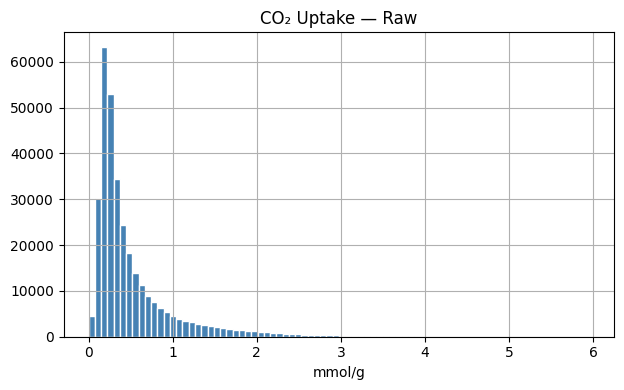

count    324426.000000
mean          0.517388
std           0.532612
min           0.000000
25%           0.204142
50%           0.319067
75%           0.605401
max           5.955197
Name: CO2_uptake_P0.15bar_T298K [mmol/g], dtype: float64


In [309]:
TARGET = 'CO2_uptake_P0.15bar_T298K [mmol/g]'

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df[TARGET].hist(bins=80, color='steelblue', edgecolor='white')
plt.title('CO₂ Uptake — Raw')
plt.xlabel('mmol/g')

"""plt.subplot(1, 2, 2)
np.log1p(df[TARGET]).hist(bins=80, color='coral', edgecolor='white')
plt.title('CO₂ Uptake — log1p transformed')
plt.xlabel('log1p(mmol/g)')"""

plt.tight_layout()
plt.show()

print(df[TARGET].describe())

##  Step 6 — Geometric Feature Distributions
These are the structural descriptors we will use as model inputs. 

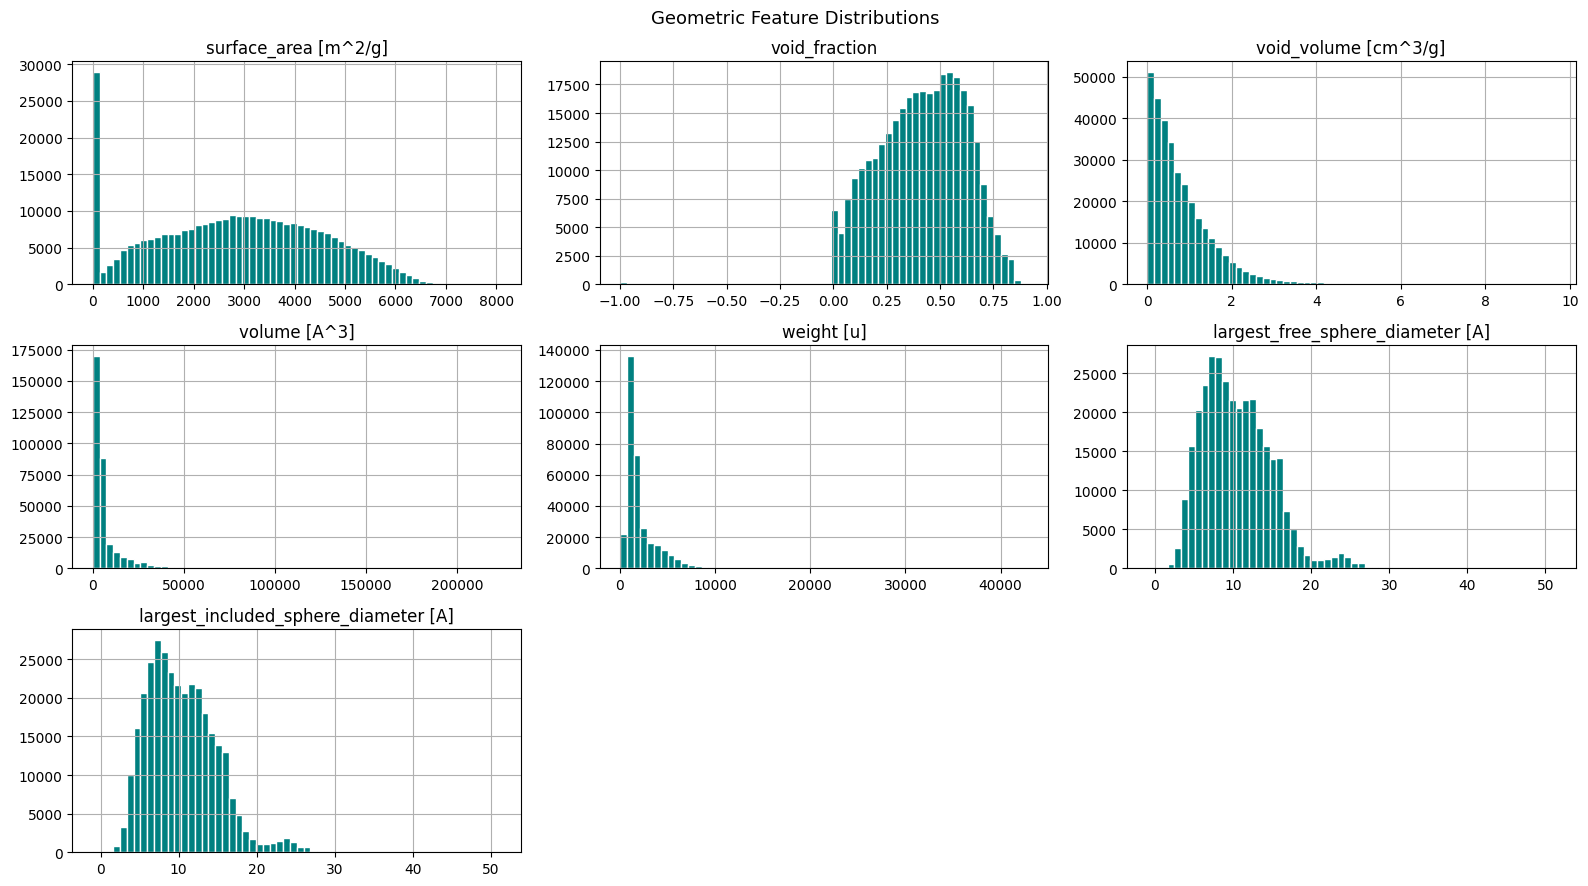

In [310]:
geo_cols = [
    'surface_area [m^2/g]', 'void_fraction',
    'void_volume [cm^3/g]', 'volume [A^3]', 'weight [u]',
    'largest_free_sphere_diameter [A]',
    'largest_included_sphere_diameter [A]'
]

df[geo_cols].hist(bins=60, figsize=(16, 9), color='teal', edgecolor='white')
plt.suptitle('Geometric Feature Distributions', fontsize=13)
plt.tight_layout()
plt.show()

##  Step 7 — Correlation Heatmap
Shows how strongly each geometric feature correlates with CO₂ uptake.Values close to +1 or -1 = strong relationship with target.  

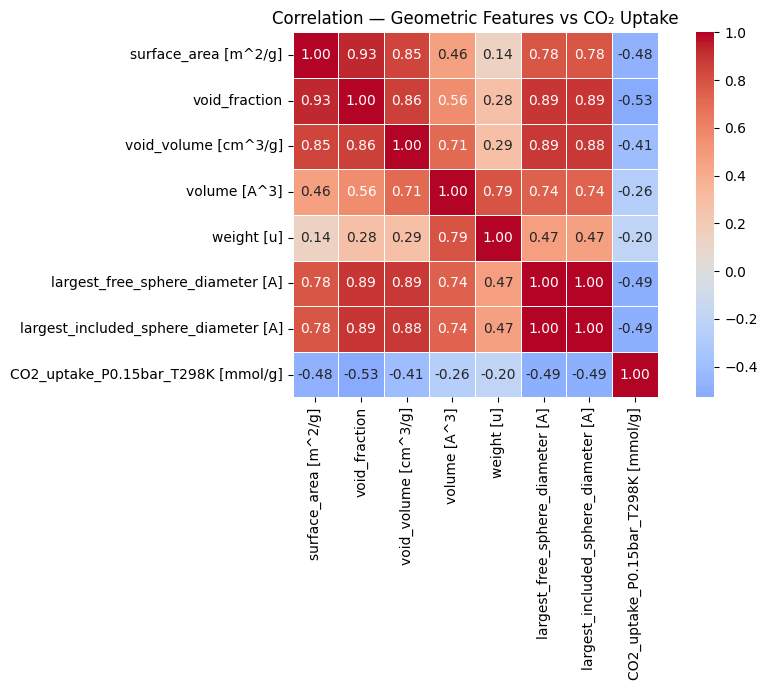

In [311]:
corr_cols = geo_cols + [TARGET]

plt.figure(figsize=(10, 7))
sns.heatmap(
    df[corr_cols].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    square=True, linewidths=0.5
)
plt.title('Correlation — Geometric Features vs CO₂ Uptake')
plt.tight_layout()
plt.show()


##  Step 8 — Categorical Columns Overview
Check how many unique values each categorical column has —  
this decides which encoding strategy we use later.

In [312]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"{col:30s} → {df[col].nunique()} unique values")

MOFname                        → 324426 unique values
functional_groups              → 400 unique values
topology                       → 11 unique values


C:\Users\HP\AppData\Local\Temp\ipykernel_18116\3239662066.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [313]:
"""linker_cols = ['organic_linker1', 'organic_linker2']

for col in linker_cols:
    print(f"{col} → {df[col].nunique()} unique values")
    print(f"Top 5 most common:")
    print(df[col].value_counts().head())
    print()"""

'linker_cols = [\'organic_linker1\', \'organic_linker2\']\n\nfor col in linker_cols:\n    print(f"{col} → {df[col].nunique()} unique values")\n    print(f"Top 5 most common:")\n    print(df[col].value_counts().head())\n    print()'

##  Step 9 — Data Cleaning

In [314]:
error_cols = [c for c in df.columns if 'error' in c.lower()]
print("Dropping:", error_cols)
df = df.drop(columns=error_cols)
print("\nShape after dropping error cols:", df.shape)

Dropping: ['CO2_uptake_error_P0.15bar_T298K [mmol/g]', 'heat_adsorption_error_CO2_P0.15bar_T298K [kcal/mol]', 'CO2_uptake_error_P0.10bar_T363K [mmol/g]', 'heat_adsorption_error_CO2_P0.10bar_T363K [kcal/mol]', 'CO2_uptake_error_P0.70bar_T413K [mmol/g]', 'heat_adsorption_error_CO2_P0.70bar_T413K [kcal/mol]', 'CO2_binary_uptake_error_P0.15bar_T298K [mmol/g]', 'heat_adsorption_error_CO2_binary_P0.15bar_T298K [kcal/mol]', 'N2_binary_uptake_error_P0.85bar_T298K [mmol/g]', 'heat_adsorption_error_N2_binary_P0.85bar_T298K [kcal/mol]']

Shape after dropping error cols: (324426, 32)


In [315]:
todrop = [
    'heat_adsorption_CO2_P0.15bar_T298K [kcal/mol]',
    'excess_CO2_uptake_P0.15bar_T298K [mmol/g]',
    'CO2_uptake_P0.10bar_T363K [mmol/g]',
    'heat_adsorption_CO2_P0.10bar_T363K [kcal/mol]',
    'excess_CO2_uptake_P0.10bar_T363K [mmol/g]',
    'CO2_uptake_P0.70bar_T413K [mmol/g]',
    'heat_adsorption_CO2_P0.70bar_T413K [kcal/mol]',
    'excess_CO2_uptake_P0.70bar_T413K [mmol/g]',
    'working_capacity_vacuum_swing [mmol/g]',
    'working_capacity_temperature_swing [mmol/g]',
    'CO2_binary_uptake_P0.15bar_T298K [mmol/g]',
    'heat_adsorption_CO2_binary_P0.15bar_T298K [kcal/mol]',
    'excess_CO2_binary_uptake_P0.15bar_T298K [mmol/g]',
    'N2_binary_uptake_P0.85bar_T298K [mmol/g]',
    'heat_adsorption_N2_binary_P0.85bar_T298K [kcal/mol]',
    'excess_N2_binary_uptake_P0.85bar_T298K [mmol/g]',
    #'CO2/N2_selectivity',
]
df = df.drop(columns=['MOFname'])
df = df.drop(columns=todrop)
df.shape

(324426, 15)

In [316]:
#Handle Missing Values
df.dropna(inplace=True)


In [317]:
print("Final shape:", df.shape)
print("Null values remaining:", df.isnull().sum().sum())
print("\nRemaining columns:")
print(df.columns.tolist())

Final shape: (322429, 15)
Null values remaining: 0

Remaining columns:
['CO2_uptake_P0.15bar_T298K [mmol/g]', 'CO2/N2_selectivity', 'volume [A^3]', 'weight [u]', 'surface_area [m^2/g]', 'void_fraction', 'void_volume [cm^3/g]', 'largest_free_sphere_diameter [A]', 'largest_included_sphere_along_free_sphere_path_diameter [A]', 'largest_included_sphere_diameter [A]', 'functional_groups', 'metal_linker', 'organic_linker1', 'organic_linker2', 'topology']


##  Step 10 — Encoding Categorical Columns
Machine learning models only understand numbers.
We have 3 categorical columns, each needing a different strategy:

| Column | Unique Values | Strategy |
|---|---|---|
| `functional_groups` | ~400 | Frequency Encoding |
| `topology` | 11 | One-Hot Encoding |
| `metal_linker` | 7 | One-Hot Encoding |
| `organic_linker1/2` | 58 | Already integers  |

In [318]:
# Frequency encoding for functional_groups column and one hot encoding for topology and metal linker column
freq = df['functional_groups'].value_counts()
df['functional_groups'] = df['functional_groups'].map(freq)
print("Frequency encoded: functional_groups")
df = pd.get_dummies(df, columns=['topology','metal_linker'])

print("One-hot encoded: topology and metal linkers")
print("\nNew shape:", df.shape)
print("New columns:", df.columns.tolist())

Frequency encoded: functional_groups
One-hot encoded: topology and metal linkers

New shape: (322429, 31)
New columns: ['CO2_uptake_P0.15bar_T298K [mmol/g]', 'CO2/N2_selectivity', 'volume [A^3]', 'weight [u]', 'surface_area [m^2/g]', 'void_fraction', 'void_volume [cm^3/g]', 'largest_free_sphere_diameter [A]', 'largest_included_sphere_along_free_sphere_path_diameter [A]', 'largest_included_sphere_diameter [A]', 'functional_groups', 'organic_linker1', 'organic_linker2', 'topology_acs', 'topology_bcu', 'topology_etb', 'topology_fof', 'topology_nbo', 'topology_pcu', 'topology_pts', 'topology_rht', 'topology_sra', 'topology_tbo', 'topology_the', 'metal_linker_1', 'metal_linker_2', 'metal_linker_3', 'metal_linker_4', 'metal_linker_9', 'metal_linker_10', 'metal_linker_12']


In [319]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [320]:
df.dtypes

CO2_uptake_P0.15bar_T298K [mmol/g]                             float64
CO2/N2_selectivity                                             float64
volume [A^3]                                                   float64
weight [u]                                                     float64
surface_area [m^2/g]                                           float64
void_fraction                                                  float64
void_volume [cm^3/g]                                           float64
largest_free_sphere_diameter [A]                               float64
largest_included_sphere_along_free_sphere_path_diameter [A]    float64
largest_included_sphere_diameter [A]                           float64
functional_groups                                                int64
organic_linker1                                                  int64
organic_linker2                                                  int64
topology_acs                                                     int64
topolo

##  Step 12 — Define x and y
Separate the dataset into:
- **x** — all input features (geometry + encoded categoricals)
- **y** — target variable (CO₂ uptake)


In [321]:
df_model = df.copy()

In [322]:
TARGET = 'CO2_uptake_P0.15bar_T298K [mmol/g]'
y = df[TARGET]
x = df.drop(columns=[TARGET])
x = x.select_dtypes(include='number')
print("x shape:", x.shape)
print("y.shape:", y.shape)
print("\nFeatures going into model:")
print(x.columns.tolist())

x shape: (322429, 30)
y.shape: (322429,)

Features going into model:
['CO2/N2_selectivity', 'volume [A^3]', 'weight [u]', 'surface_area [m^2/g]', 'void_fraction', 'void_volume [cm^3/g]', 'largest_free_sphere_diameter [A]', 'largest_included_sphere_along_free_sphere_path_diameter [A]', 'largest_included_sphere_diameter [A]', 'functional_groups', 'organic_linker1', 'organic_linker2', 'topology_acs', 'topology_bcu', 'topology_etb', 'topology_fof', 'topology_nbo', 'topology_pcu', 'topology_pts', 'topology_rht', 'topology_sra', 'topology_tbo', 'topology_the', 'metal_linker_1', 'metal_linker_2', 'metal_linker_3', 'metal_linker_4', 'metal_linker_9', 'metal_linker_10', 'metal_linker_12']


##  Step 13 — Train / Validation / Test Split (70 / 15 / 15)

Three separate sets:
- **Train (70%)** — model learns from this
- **Validation (15%)** — monitors overfitting during training via early stopping
- **Test (15%)** — completely untouched until final evaluation

In [323]:
x_train, x_temp, y_train, y_temp = train_test_split(
    x, y,
    test_size=0.30,
    random_state=42
)
x_test, x_val, y_test, y_val = train_test_split(
    x_temp, y_temp, 
    test_size=0.50, 
    random_state=42
)
print("Training rows:   ", x_train.shape[0])   
print("Validation rows: ", x_val.shape[0])     
print("Test rows:       ", x_test.shape[0]) 

Training rows:    225700
Validation rows:  48365
Test rows:        48364


##  Step 15 — Random Forest Regressor

In [324]:
rf = RandomForestRegressor(
    n_estimators=100,
      max_depth=20,
   min_samples_split=7,
    min_samples_leaf=3,
    # minimum rows required in each leaf node
    # 1 = very detailed trees
    # try values 1, 2, 4 and compare
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf.fit(x_train, y_train)

y_pred_train = rf.predict(x_train)
#y_pred_val   = rf.predict(x_val)
y_pred_test  = rf.predict(x_test)

r2_train = r2_score(y_train, y_pred_train)
#r2_val   = r2_score(y_val,   y_pred_val)
r2_test  = r2_score(y_test,  y_pred_test)

print(f"Train R² : {r2_train:.4f}")
#print(f"Val   R² : {r2_val:.4f}")
print(f"Test  R² : {r2_test:.4f}")
print(f"Gap      : {r2_train - r2_test:.4f}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   13.2s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.6s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    1.9s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s


Train R² : 0.9481
Test  R² : 0.9042
Gap      : 0.0439


[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.3s finished
